In [1]:
import pandas as pd
import geopandas as gpd
import os
import numpy as np
import pyarrow.parquet as pq
from shapely.geometry import LineString, MultiLineString


import matplotlib.pyplot as plt
import seaborn as sns
import calendar
import shapely as wkt
import ast
import re

import folium  # For plots of geometry on interactive map
import matplotlib.colors as mcolors
import random

import plotly.express as px
import plotly.io as pio

pio.renderers.default = "colab"  # or: "notebook_connected"
from plotly.graph_objs import Font

import sys
from pathlib import Path

DATA_DIR = Path.cwd().parent / "data"
print("Data directory:", DATA_DIR.resolve())

Data directory: /Users/licin/OptimalChargerPlacement/data


In [2]:
MONTH = 6
HOUR = 20

Need a list of census blocks in Alameda county
Get list of intersecting feeders from metatadata of all CA feeders
Get Feeder data for only feeders intersectiing alameda county census blocks



### CENSUS BLOCK DATA FROM THIBAUD - Get census block geodataframe for alameda county  



import census block geodataframe from  shp file  
filter to only alameda county census blocks

In [3]:
# Import Census tract data
def import_census_block_gdf_for_charging(base_path=DATA_DIR):
    relative_folder_path = "Geography_Files"
    filename = "location_str_to_geoid_mapping.shp"
    file_path = os.path.join(base_path, relative_folder_path, filename)
    gdf = gpd.read_file(file_path)
    return gdf

def get_census_block_gdf_almada_charging():
    """
    Get census block geodataframe for Alameda county
    """
    df = import_census_block_gdf_for_charging()
    df = df[df["GEOID_STR"].str.contains("Alameda")]
    return df

alamedaCensusGdf = get_census_block_gdf_almada_charging()
display(alamedaCensusGdf.head())



,GEOID,GEOID_STR,INTPTLAT,INTPTLON,geometry
0,060014232002,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"POLYGON ((-122.29678 37.86529, -122.29581 37.8..."
2,060014043002,"2 (Tract 4043, Alameda, CA)",37.844708,-122.241138,"POLYGON ((-122.24813 37.84139, -122.24749 37.8..."
15,060014062022,"2 (Tract 4062.02, Alameda, CA)",37.780027,-122.228022,"POLYGON ((-122.23135 37.78091, -122.23094 37.7..."
29,060014327003,"3 (Tract 4327, Alameda, CA)",37.725139,-122.144137,"POLYGON ((-122.14782 37.72717, -122.14747 37.7..."
54,060014415232,"2 (Tract 4415.23, Alameda, CA)",37.562874,-122.047237,"POLYGON ((-122.05046 37.56346, -122.05028 37.5..."


### Grid Metadata and Geometry
Raw data file is for the entire state of California.
ADD FILTER TO ONLY INCLUDE ALAMEDA COUNTY

In [4]:
# Import metadata geodataframe for all feeders
# 1 row for each feeder
# 'feeder_id'	'division'	'substation'	'nom_volt_kV'	'Existing_DG'	'Queued_DG'	'shape_length'	'geometry'


def import_metaData_gdf_all_feeders(base_path=DATA_DIR):

    relative_folder_path = "cleanedGridData"
    filename = "feeder_meta_clean_gdf.gpkg"
    file_path = os.path.join(base_path, relative_folder_path, filename)
    gdf_all_feeders = gpd.read_file(file_path)
    return gdf_all_feeders


feederMetadataGdf = import_metaData_gdf_all_feeders()
display(feederMetadataGdf.head())

,feeder_id,division,substation,nom_volt_kV,Existing_DG,Queued_DG,shape_length,geometry
0,163201102,Stockton,WEST POINT,12kV,2340,370,431704.873501,"MULTILINESTRING ((717038.22 4245680.843, 71703..."
1,083432111,San Jose,HICKS,21kV,4720,730,61473.923814,"MULTILINESTRING ((600661.102 4121410.616, 6006..."
2,022101109,Peninsula,SF H,12kV,1520,80,25925.744324,"MULTILINESTRING ((551452.358 4173482.555, 5513..."
3,043302103,Sonoma,MONROE,21kV,10210,1040,109445.067948,"MULTILINESTRING ((522459.857 4258793.177, 5224..."
4,162671103,Yosemite,WESTLEY,12kV,1870,5440,161530.404081,"MULTILINESTRING ((652837.489 4156520.205, 6527..."


In [5]:
# Find all feeders in feederMetadataGdf located in San Francisco (divission == "San Francisco")
sanFranciscoFeeders = feederMetadataGdf[
    feederMetadataGdf["division"] == "San Francisco"
]["feeder_id"].tolist()
#print(sanFranciscoFeeders)

### Create intersection matrix, find all feeders that intersect Alameda county census blocks

In [6]:
def get_feeder_census_block_intersection_matrix(feederGdf, censusGdf, verbose=False):
    # CRS for Bay Area can be set to 32610 (when working in meters)
    # CRS for some parts of California need to be adjusted
    blocks_proj_m = alamedaCensusGdf.to_crs(epsg=32610)
    feeders_proj_m = feederMetadataGdf.to_crs(epsg=32610)

    # spatial join to find intersections between feeders and census blocks
    intersections = gpd.overlay(feeders_proj_m, blocks_proj_m, how="intersection")
    
    # length of each feeder segment in each block
    intersections["length_in_block_m"] = intersections.geometry.apply(get_length)

    # total length per block
    block_totals = (
        intersections.groupby("GEOID")["length_in_block_m"]
        .sum()
        .rename("total_length_in_block"))
    
    # merge total length per block back to intersections
    intersections = intersections.merge(block_totals, on="GEOID")

    # Fraction of a feeder lenth in a block over total length of all feeders in that block
    intersections["fraction"] = (intersections["length_in_block_m"] / intersections["total_length_in_block"])

    feeder_block_matrix = intersections.pivot_table(
        index="feeder_id",  # replace with your feeder ID column
        columns="GEOID",
        values="fraction",
        fill_value=0,)
    
    if verbose:
        display(feeder_block_matrix)
        # CHECKING THE INTERSECTION WORKED CORRECTLY
        # Add row to feeder_block_matrix which is the sum of each column
        court_row = pd.DataFrame(feeder_block_matrix.sum(axis=0)).T
        court_row.index = ["Court_Sum"]
        vals = feeder_block_matrix.sum(axis=0).unique()
        np.set_printoptions(precision=4)
        print(f"All block cols sum to {vals}")
        
    return feeder_block_matrix

def get_length(geom):
    if geom.is_empty:
        return 0
    elif isinstance(geom, LineString):
        return geom.length
    elif isinstance(geom, MultiLineString):
        return sum(line.length for line in geom.geoms)
    else:
        # GeometryCollection: sum only LineStrings
        return sum(g.length for g in geom.geoms if isinstance(g, LineString))

feederBlockMtxAlameda = get_feeder_census_block_intersection_matrix(feederMetadataGdf, alamedaCensusGdf, verbose=True)

GEOID,060014001001,060014001002,060014002001,060014002002,060014003001,060014003002,060014003003,060014003004,060014004001,060014004002,...,060014517031,060014517032,060014517041,060014517042,060014517043,060019819001,060019820001,060019821001,060019832001,060019832002
feeder_id,,,,,,,,,,,,,,,,,,,,,
012011101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.027052,0.000000
012011102,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.003189,0.0,0.075951,0.003121
012011103,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.003623,0.0,0.024106,0.000000
012011104,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.059989,0.000000
012011105,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.066367,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
014722111,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000
082831109,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000
163741102,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000


All block cols sum to [1. 1. 1. 1.]


In [7]:
# get list of all feeders from the feeder_id in feederBlockMtxAlameda
alamedaFeedersList = feederBlockMtxAlameda.index.tolist()
# Convert list of strings to list of integers
alamedaFeedersAsIntsList = [int(feeder) for feeder in alamedaFeedersList]

# list of all columns in feederBlockMtxAlameda
alamedaBlocksGeoIdList = feederBlockMtxAlameda.columns.tolist()
#print(alamedaBlocksGeoIdList)

# get list of alamedaCensusGdf['GEOID_STR'] corresponding to alamedaBlocksGeoIdStrList
alamedaBlocksGeoIdStrList = alamedaCensusGdf[alamedaCensusGdf['GEOID'].isin(alamedaBlocksGeoIdList)]['GEOID_STR'].tolist()
#print(alamedaBlocksGeoIdStrList)

# Create a dictionary mapping from GEOID to GEOID_STR for Alameda county
geoid_to_geoidstr_alameda = dict(zip(alamedaCensusGdf['GEOID'], alamedaCensusGdf['GEOID_STR']))
geoidstr_to_geoid_alameda = dict(zip(alamedaCensusGdf['GEOID_STR'], alamedaCensusGdf['GEOID']))


In [8]:
# Save feederBlockMtxAlameda to csv
output_filename = "feederBlockIntersectionMtx.csv"
output_filepath = os.path.join(DATA_DIR, "OptimizationInput", output_filename)
feederBlockMtxAlameda.to_csv(output_filepath, index=False)

### EV Projection Data for Census Blocks

In [28]:
# HELPER FUNCTIONS FOR EV LOAD CURVES

def import_ev_projection_df(year, type="unmanaged"):
    """
    Import raw ev projection csv as dataframe.
    Limited to Alameda county and 2025 or 2035 projections
    Given one day of 15 min data for load curves as a string, convert the string to list of floats
    """
    if type not in ["managed", "unmanaged", "all"]:
        raise ValueError("type must be 'managed', 'unmanaged', or 'all'")
    if year not in [ "full_ev_adoption_alameda_load_curves.csv", "2035", "2025"]:
        raise ValueError("year must be 'full_ev_adoption_alameda_load_curves.csv', '2035', or '2025'")

    if type == "unmanaged":
        if year == "full_adoption":
            rel_file_path = "full_ev_adoption_alameda_load_curves.csv"
        elif year == "2035":
            rel_file_path = "sim_20251117_alameda_2035_adoption/ev_load_curves.csv"
        elif year == "2025":
            rel_file_path = "sim_20251117_alameda_2025_adoption/ev_load_curves.csv"

    elif type == "managed":
        if year == "full_adoption":
            rel_file_path = "full_ev_adoption_alameda_load_curves.csv"
        elif year == "2035":
            rel_file_path = "sim_20251121_alameda_2035_managed_naive/ev_load_curves.csv"
        elif year == "2025":
            rel_file_path = "sim_20251121_alameda_2025_managed_naive/ev_load_curves.csv"

    print(year)
    file_path = os.path.join(DATA_DIR, "EvChargingLoadCurves", rel_file_path)
    df = pd.read_csv(file_path)
    
    # Convert string "[...]" → Python list of floats
    if "load_curve" in df.columns:
        df["load_curve"] = df["load_curve"].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x
        )
    return df


# ev_projection_df = import_ev_projection_df("2035", type="managed")
# display(ev_projection_df.head())


def expand_load_curve_to_hourly(df, method="mean"):
    """
    Expands one day of 15 min load curves (96 points) into 24 hourly columns.

    INPUT: 
    df - from import_ev_projection_df() with a column named 'load_curve' containing list of 96 floats
    method ("mean" or "max") - how to aggregate 4 15 min values into one hour value

    RETURN: 
    df - Replaces the list of 15 min load data in input df with 24 columns for hourly load
    """

    if method not in ["mean", "max"]:
        raise ValueError("method must be 'mean' or 'max'")

    # Function to aggregate one row’s curve into 24 hourly values
    def aggregate_curve(curve):
        curve = np.array(curve)
        hourly = []
        for h in range(24):
            block = curve[h * 4 : (h + 1) * 4]
            if method == "mean":
                hourly.append(block.mean())
            else:  # method == "max"
                hourly.append(block.max())
        return hourly

    # Expand into a DataFrame
    hourly_expanded = df["load_curve"].apply(aggregate_curve)
    hourly_df = pd.DataFrame(
        hourly_expanded.tolist(), columns=[f"{i}" for i in range(24)]
    )

    # Return original df + new columns
    return pd.concat([df.drop(columns=["load_curve"]), hourly_df], axis=1)

# hrly = expand_load_curve_to_hourly(ev_projection_df, method="mean")
# display(hrly.head())
# # list all unique values in charger type column
# print(ev_projection_df["charger_type"].unique())

def sum_EVloads_in_blockGrp_for_type(df, charger_type="all"):
    """Sums ev loads in each block group by charger type (public, private, all). 
    Ensures every geoid appears in output."""
    public_types = [
        "Public_HD_Long_Duration_DCFC_150_kW", "Public_HD_Long_Duration_DCFC_350_kW",
        "Public_MD_Long_Duration_DCFC_150_kW", "Public_MD_Long_Duration_DCFC_50_kW",
        "Public_MD_Long_Duration_L2_11_kW", "Public_MD_Opportunistic_DCFC_350_kW",
        "Public_MD_Opportunistic_DCFC_50_kW", "Public_LD_L2_11_KW",
        "Public_LD_DCFC_150_kW", "Public_LD_DCFC_250_kW",
        "Public_LD_DCFC_350_kW", "Public_HD_Long_Duration_DCFC_50_kW",
        "Public_HD_Long_Duration_DCFC_750_kW", "Public_HD_Opportunistic_DCFC_350_kW",
        "Public_MD_Opportunistic_DCFC_1000_kW", "Public_HD_Opportunistic_DCFC_50_kW",
        "Public_HD_Opportunistic_DCFC_1000_kW",
    ]

    private_types = ["SFH_LD_L2", "Work_LD_L2", "MFH_LD_L2"]

    if charger_type == "all":
        filtered_df = df.copy()
    elif charger_type == "public":
        filtered_df = df[df["charger_type"].isin(public_types)].copy()
    else:  # private
        filtered_df = df[df["charger_type"].isin(private_types)].copy()

    hourly_cols = [str(i) for i in range(24)]

    # --- CORE FIX: ensure every geoid appears ---
    all_geoids = df["geoid"].unique()

    summed_df = (
        filtered_df.groupby("geoid")[hourly_cols]
        .sum()
        .reindex(all_geoids, fill_value=0)  # <--- THIS LINE FIXES THE PROBLEM
        .reset_index()
    )

    return summed_df
# summed_loads_public = sum_EVloads_in_blockGrp_for_type(hrly, charger_type="public")
# display(summed_loads_public.head())
# summed_loads_private = sum_EVloads_in_blockGrp_for_type(hrly, charger_type="private")
# display(summed_loads_private.head())
# summed_loads_all = sum_EVloads_in_blockGrp_for_type(hrly, charger_type="all")
# display(summed_loads_all.head())



In [32]:
def get_clean_EV_load_df(year='2025', chargerType='all', scenario="unmanaged", method="mean", geoIDStrList=None):
    """
    Returns a cleaned EV load DataFrame 
    from file for a given year, charger type, scenario. 
    Selects method for aggregating 15 min load data to hour (mean or sum).
    """
    EvProjDf = import_ev_projection_df(year, scenario)
    EvProjDf = expand_load_curve_to_hourly(EvProjDf, method=method)
    EvProjDf = sum_EVloads_in_blockGrp_for_type(EvProjDf, charger_type=chargerType)
    if geoIDStrList is not None:
        # filter EvProjDf to only geoIDs in geoIDStrList, if EVProjDf does not include them all add them with 0 load in cols ['0'] through ['23']
        EvProjDf = EvProjDf[EvProjDf['geoid'].isin(geoIDStrList)].copy()
        missing_geoids = set(geoIDStrList) - set(EvProjDf['geoid'])
        for missing_geoid in missing_geoids:
            zero_loads = {str(i): 0 for i in range(24)}
            new_row = {'geoid': missing_geoid, **zero_loads}
            EvProjDf = EvProjDf.append(new_row, ignore_index=True) 
    
    # # rename column from 'geoid' to 'geoid_str'
    # EvProjDf = EvProjDf.rename(columns={"geoid": "geoid_str"})  
    # # Add column for geoid using geoid_str and map from geoid_to_geoidstr_alameda mapping
    # EvProjDf["geoid"] = EvProjDf["geoid_str"].map(geoidstr_to_geoid_alameda)
    # # make geoid the first column
    # cols = EvProjDf.columns.tolist()
    # cols = ['geoid'] + [col for col in cols if col != 'geoid']
    # EvProjDf = EvProjDf[cols]

    return EvProjDf
evLoad2035Df = get_clean_EV_load_df(year='2035', chargerType='all', scenario="managed", method="mean")
display(evLoad2035Df.head())

2035


,geoid,0,1,2,3,4,5,6,7,8,...,14,15,16,17,18,19,20,21,22,23
0,"0 (Tract 9900, Alameda, CA)",11.2,11.2,11.2,11.2,11.2,11.200000,11.2,2.8,0.00,...,911.400001,518.7,61.950000,46.20,46.200,46.2,46.2,46.2,46.2,25.839984
1,"0 (Tract 9901, San Mateo, CA)",0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,236.25,...,0.000000,0.0,0.000000,0.00,0.000,0.0,0.0,0.0,0.0,0.000000
2,"1 (Tract 1, Carson City, NV)",22.4,22.4,22.4,22.4,22.4,10.960008,0.0,0.0,0.00,...,0.000000,0.0,0.000000,0.00,0.000,0.0,0.0,5.6,22.4,22.400000
3,"1 (Tract 1, Fresno, CA)",18.4,18.4,24.0,29.6,29.6,29.600000,24.2,22.4,22.40,...,11.200000,16.6,11.600006,7.20,7.200,7.2,7.2,7.2,7.2,18.400000
4,"1 (Tract 1, Inyo, CA)",0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.00,...,0.000000,0.0,0.000000,68.25,34.125,0.0,0.0,0.0,0.0,0.000000


In [33]:
managed_evLoad2035Df = get_clean_EV_load_df(year='2035', chargerType='all', scenario="managed", method="mean")
display(managed_evLoad2035Df.head())

2035


,geoid,0,1,2,3,4,5,6,7,8,...,14,15,16,17,18,19,20,21,22,23
0,"0 (Tract 9900, Alameda, CA)",11.2,11.2,11.2,11.2,11.2,11.200000,11.2,2.8,0.00,...,911.400001,518.7,61.950000,46.20,46.200,46.2,46.2,46.2,46.2,25.839984
1,"0 (Tract 9901, San Mateo, CA)",0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,236.25,...,0.000000,0.0,0.000000,0.00,0.000,0.0,0.0,0.0,0.0,0.000000
2,"1 (Tract 1, Carson City, NV)",22.4,22.4,22.4,22.4,22.4,10.960008,0.0,0.0,0.00,...,0.000000,0.0,0.000000,0.00,0.000,0.0,0.0,5.6,22.4,22.400000
3,"1 (Tract 1, Fresno, CA)",18.4,18.4,24.0,29.6,29.6,29.600000,24.2,22.4,22.40,...,11.200000,16.6,11.600006,7.20,7.200,7.2,7.2,7.2,7.2,18.400000
4,"1 (Tract 1, Inyo, CA)",0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.00,...,0.000000,0.0,0.000000,68.25,34.125,0.0,0.0,0.0,0.0,0.000000


In [34]:
managed_evLoad2035Df.equals(evLoad2035Df)

True

In [35]:
# def get_clean_EV_growth_df(year1='2025', chargerType1='all', scenario1="unmanaged", year2='2035', chargerType2="all", scenario2="managed", method="mean", geoIDStrList=None):
#     """
#     1. Gets hourly EV load data for two years each with specific scenarios, and charger types
#     2. Computes growth from year1 to year2 for each block group given
#     """
#     # yr1EvProjDf = import_ev_projection_df(year1, scenario1, geoIDStrList=geoIDStrList)
#     # yr1EvProjDf = expand_load_curve_to_hourly(yr1EvProjDf, method=method)
#     # yr1EvProjDf = sum_EVloads_in_blockGrp_for_type(yr1EvProjDf, charger_type=chargerType1)
#     yr1EvProjDf = get_clean_EV_load_df(year1, scenario1, geoIDStrList=geoIDStrList)

#     # yr2EvProjDf = import_ev_projection_df(year2, scenario2, geoIDStrList=geoIDStrList)
#     # yr2EvProjDf = expand_load_curve_to_hourly(yr2EvProjDf, method=method)
#     # yr2EvProjDf = sum_EVloads_in_blockGrp_for_type(yr2EvProjDf, charger_type=chargerType2)
#     yr2EvProjDf = get_clean_EV_load_df(year2, scenario2, geoIDStrList=geoIDStrList)

#     # # Make a new dataframe and Subtract the hourly values of year 1 from year 2 to get growth
#     # growth_df = yr2EvProjDf.copy()
#     # hourly_cols = [str(i) for i in range(24)]
#     # # growth_df[hourly_cols] = yr2EvProjDf[hourly_cols] - yr1EvProjDf[hourly_cols]

#     hourly_cols = [str(i) for i in range(24)]

#     # --- 1. Check same geoids ---
#     geoids_2025 = set(yr1EvProjDf["geoid"])
#     geoids_2035 = set(yr2EvProjDf["geoid"])

#     missing_in_2035 = geoids_2025 - geoids_2035
#     missing_in_2025 = geoids_2035 - geoids_2025

#     if missing_in_2035 or missing_in_2025:
#         raise ValueError(
#             f"Geoids do not match.\n"
#             f"Missing in 2035: {missing_in_2035}\n"
#             f"Missing in 2025: {missing_in_2025}"
#         )

#     # --- 2. Sort & align by geoid ---
#     df2025_sorted = yr1EvProjDf.sort_values("geoid").reset_index(drop=True)
#     df2035_sorted = yr2EvProjDf.sort_values("geoid").reset_index(drop=True)
#     print(df2025_sorted)
#     print(df2035_sorted)
#     # --- 3. Compute growth (2035 - 2025) ---
#     growth_matrix = df2035_sorted[hourly_cols].values - df2025_sorted[hourly_cols].values
#     growth_df = pd.DataFrame(growth_matrix, columns=hourly_cols)
#     growth_df.insert(0, "geoid", df2025_sorted["geoid"].values)
#     # rename column from 'geoid' to 'geoid_str'
#     growth_df = growth_df.rename(columns={"geoid": "geoid_str"})

#     # Add column for geoid using geoid_str and map from geoid_to_geoidstr_alameda mapping
#     growth_df["geoid"] = growth_df["geoid_str"].map(geoidstr_to_geoid_alameda)
#     # make geoid the first column
#     cols = growth_df.columns.tolist()
#     cols = ['geoid'] + [col for col in cols if col != 'geoid']
#     growth_df = growth_df[cols]
    

#     return growth_df

# # ev_growth_df = get_clean_EV_growth_df(year1='2025', chargerType1='all', scenario1="unmanaged", year2='2035', chargerType2="all", scenario2="managed", method="mean", geoIDStrList=alamedaBlocksGeoIdStrList)
# # display(ev_growth_df)

### Grid Data

#### Base Load Data

In [36]:
# base load data for all feeders in Alameda
# first get base load data for all feeders
# Then filter to only Alameda feeders using alamedaFeedersList


# LOAD DATA ALL FEEDERS
def import_loadDf_all_feeders(base_path=DATA_DIR):

    relative_folder_path = "cleanedGridData"
    filename = "feeder_load_profile_clean.csv"
    file_path = os.path.join(base_path, relative_folder_path, filename)
    load_df_all_feeders = pd.read_csv(file_path)

    # load_df_all_feeders = pd.read_csv(file_path, dtype={'feeder_id': str})
    return load_df_all_feeders


def get_base_load_df_for_feeders_in_list(feedersList):
    """
    Get load dataframe for only Alameda county feeders
    """
    # filter load df to feedersList.
    # If a feeder in feedersList is not in load_df_all_feeders Set up df with all month-hour combinations with NaN for "low_load_kw" and "high_load_kw" 
    load_df_all_feeders = import_loadDf_all_feeders()
    all_months = range(1, 13)
    all_hours = range(0, 24)
    all_combinations = pd.MultiIndex.from_product(
        [feedersList, all_months, all_hours],
        names=["feeder_id", "month", "hour"]
    )
    all_combinations_df = pd.DataFrame(index=all_combinations).reset_index()
    filteredDf = all_combinations_df.merge(
        load_df_all_feeders,
        on=["feeder_id", "month", "hour"],
        how="left"
    )
    
    
    # load_df_all_feeders = import_loadDf_all_feeders()
    # filteredDf = load_df_all_feeders[
    #     load_df_all_feeders["feeder_id"].isin(feedersList)
    # ].copy()
    
    return filteredDf

def get_base_load_df_for_timeslice_and_type(df, month, hour, low_or_high='high'):

    filtered_df = df[(df["month"] == month) & (df["hour"] == hour)].copy()
    filtered_df = filtered_df.drop(columns=["month", "hour"])
    if low_or_high == 'high':
        # drop low column
        filtered_df = filtered_df.drop(columns=["low_load_kw"])
    elif low_or_high == 'low':
        # drop high column
        filtered_df = filtered_df.drop(columns=["high_load_kw"])
    else:
        raise ValueError("low_or_high must be 'low' or 'high'")

    return filtered_df


alamedaFeedersBaseLoadDf = get_base_load_df_for_feeders_in_list(alamedaFeedersAsIntsList)
display(alamedaFeedersBaseLoadDf.head())

alamedaBaseLoadDf_slice = get_base_load_df_for_timeslice_and_type(alamedaFeedersBaseLoadDf, MONTH, HOUR, low_or_high='high')
display(alamedaBaseLoadDf_slice)

# # Save alamedaBaseLoadDf_slice as alamedaBaseLoadDf_slice_month{MONTH}_hour{HOUR}.csv
output_filename = f"alamedaBaseLoadDf_slice_month{MONTH}_hour{HOUR}.csv"
output_filepath = os.path.join(DATA_DIR, "OptimizationInput", output_filename)
alamedaBaseLoadDf_slice.to_csv(output_filepath, index=False)

,feeder_id,month,hour,low_load_kw,high_load_kw
0,12011101,1,0,NaN,NaN
1,12011101,1,1,NaN,NaN
2,12011101,1,2,NaN,NaN
3,12011101,1,3,NaN,NaN
4,12011101,1,4,NaN,NaN


,feeder_id,high_load_kw
140,12011101,NaN
428,12011102,NaN
716,12011103,NaN
1004,12011104,NaN
1292,12011105,NaN
...,...,...
85964,14722111,NaN
86252,82831109,6857.0
86540,163741102,5662.0
86828,163741103,2305.0


#### ICA DATA
import ICA load cap data for given set of feeders, only keep specified columns, or only keep min ICA data
import a single feeders ICA data only keeping specified columns

RAW LINE PARQUET TO FEEDER AGGREGATION
import raw parquet data for a given feeders lines, only keep specific columns
aggregate line data to get feeder level statistics


FOR ALL FEEDERS IN A LIST (ALAMEDA)
Get df of mine ICA with repect to time for all feeders in alameda county
Then just take the one specific time slice for all feeders in alameda county





In [37]:
# Import ICA data from parquet files
def get_FeederMinIcaDf_from_parquet(feeder_id, verbose=True, base_path=DATA_DIR, ):
    """
    get_feeder_ICA_df_from_parquet, remove some columns, and aggregat all IC data to min IC per line month-hour

    :feeder_id: Feeder ID whose ICA data you want
    :folder_path: Path to the folder in Google Drive that holds the .parquet files
    :return: Pandas DataFrame
    """
    # Drop division column as it is already in metadata for each feeder

    relative_folder_path = "cleanedGridData/ICA_Load_CLEAN_PARQUET_v4"
    filename = f"{feeder_id}.parquet"
    file_path = os.path.join(base_path, relative_folder_path, filename)
    missingFeeder = None

    # If file does not exist, return dataframe with nan values for all columns except feeder_id
    if not os.path.exists(file_path):
        missingFeeder = feeder_id  
        if verbose:
            print(f"File not found: {feeder_id}")

        # create dataframe from cols_to_keep use given feeder_id and nan for all other columns
        cols = ["feeder_id", "month", "hour", "IC_min_kW"]
        df = pd.DataFrame(columns=cols)
        
        # Set up df with all month-hour combinations with NaN IC_min_kW
        df = pd.DataFrame([(feeder_id, month, hour, np.nan) for month in range(1, 13) for hour in range(24)], columns=cols)
        
        if verbose:
            display(df.head())

        return df, missingFeeder

    cols_to_keep = [
        "line_section_id", "month", "hour", "feeder_id",
        "IC10_Thermal_KW", "IC10_Voltage_KW",
        "IC90_Thermal_KW", "IC90_Voltage_KW"
    ]    
    table = pq.read_table(file_path, columns=cols_to_keep)
    df = table.to_pandas()

    # Combine IC columns into single IC_min column
    ic_cols = [
        "IC10_Thermal_KW", "IC10_Voltage_KW",
        "IC90_Thermal_KW", "IC90_Voltage_KW"
    ]

    df["IC_min_kW"] = df[ic_cols].min(axis=1)
    df = df.drop(columns=ic_cols)

    # Aggregate line data to feeder-month-hour level by taking mean of IC_min for all lines in feeder
    agg_df = df.groupby(["feeder_id", "month", "hour"], as_index=False).agg({"IC_min_kW": "mean"})

    # only return missingFeeder if it is defined

    return agg_df, missingFeeder

(df, missingFeeder) = get_FeederMinIcaDf_from_parquet("163201102")
display(df.head())

,feeder_id,month,hour,IC_min_kW
0,163201102,1,0,669.080933
1,163201102,1,1,699.204956
2,163201102,1,2,711.028442
3,163201102,1,3,710.940918
4,163201102,1,4,710.430359


In [38]:
def get_allMinICA_df_for_feeders(feeder_id_list, base_path=DATA_DIR):
    """
    For a list of feeder IDs, get their min ICA data DataFrames and concatenate into one DataFrame.

    :feeder_ids: List of feeder IDs
    :base_path: Base path to data directory
    :return: Concatenated Pandas DataFrame of min ICA data for all feeders
    """
    df_list = []
    missingFeederList = []
    for feeder_id in feeder_id_list:
        (df, missing_feeder) = get_FeederMinIcaDf_from_parquet(feeder_id, verbose=False, base_path=base_path)
        if missing_feeder is not None:
            missingFeederList.append(missing_feeder)
        df_list.append(df)

    combined_df = pd.concat(df_list, ignore_index=True)

    print(f"Missing feeders: {missingFeederList}")
    return combined_df
alamedaMinICA = get_allMinICA_df_for_feeders(alamedaFeedersList)

alamedaMinICA

Missing feeders: ['012011101', '012011102', '012011103', '012011104', '012011105', '012011106', '012041104', '012041112', '012060406', '012111111', '012111112', '012111113', '012111114', '012111115', '012111116', '013681111', '014722102']


/var/folders/zv/7h23jkj12tl1zd_4bsx6h9wr0000gn/T/ipykernel_16341/2175899076.py:17: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



,feeder_id,month,hour,IC_min_kW
0,012011101,1,0,NaN
1,012011101,1,1,NaN
2,012011101,1,2,NaN
3,012011101,1,3,NaN
4,012011101,1,4,NaN
...,...,...,...,...
87259,169951101,12,19,1680.259033
87260,169951101,12,20,1257.512939
87261,169951101,12,21,1221.792725
87262,169951101,12,22,1106.435181


In [39]:
def get_minICA_df_time_slice(df, month, hour):
    """
    Given a DataFrame of min ICA data for multiple feeders,
    return a DataFrame with min ICA values at a specific month-hour time slice.

    :df: DataFrame with columns ['feeder_id', 'month', 'hour', 'IC_min_kW']
    :month: Month (1-12) to filter on
    :hour: Hour (0-23) to filter on
    :return: Filtered DataFrame with min ICA values at the specified time slice
    """
    # if a feeder has a nan value for IC_min_kW at the given month-hour, it should still appear in output with nan value
    filtered_df = df[(df['month'] == month) & (df['hour'] == hour)].copy()
    
    # Rename IC_min_kW column to indicate the time slice
    # filtered_df = filtered_df.rename(columns={'IC_min_kW': f'IC_min_kW_mon{month}_hr{hour}'})
    
    # drop month and hour columns
    filtered_df = filtered_df.drop(columns=['month', 'hour'])
    return filtered_df

df_minICA_Alameda_slice = get_minICA_df_time_slice(alamedaMinICA, month=MONTH, hour=HOUR)
display(df_minICA_Alameda_slice)

output_filename = f"alamedaMinICA_slice_month{MONTH}_hour{HOUR}.csv"
output_filepath = os.path.join(DATA_DIR, "OptimizationInput", output_filename)
df_minICA_Alameda_slice.to_csv(output_filepath, index=False)

,feeder_id,IC_min_kW
140,012011101,NaN
428,012011102,NaN
716,012011103,NaN
1004,012011104,NaN
1292,012011105,NaN
...,...,...
85964,014722111,4084.223389
86252,082831109,1269.246460
86540,163741102,224.941498
86828,163741103,357.686096


In [40]:
# Create mapping from descriptive string to numeric GEOID
geoid_map = dict(zip(alamedaCensusGdf["GEOID_STR"], alamedaCensusGdf["GEOID"]))

alamedaLoad2035Df = evLoad2035Df[evLoad2035Df["geoid"].str.contains("Alameda")].copy()
# Apply the mapping
alamedaLoad2035Df["GEOID_NUM"] = alamedaLoad2035Df["geoid"].map(geoid_map)

# # Optional: check for any missing mappings
missing = alamedaLoad2035Df[alamedaLoad2035Df["GEOID_NUM"].isna()]
print("Rows with missing mapping:", missing)

alamedaLoad2035Df["geoid"] = alamedaLoad2035Df["GEOID_NUM"]
alamedaLoad2035Df = alamedaLoad2035Df.drop(columns=["GEOID_NUM"])



Rows with missing mapping: Empty DataFrame
Columns: [geoid, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, GEOID_NUM]
Index: []

[0 rows x 26 columns]


In [41]:
alamedaLoad2035Df

,geoid,0,1,2,3,4,5,6,7,8,...,14,15,16,17,18,19,20,21,22,23
0,060019900000,11.200000,11.200000,11.200000,11.200000,11.200000,11.200000,11.200000,2.800000,0.000000,...,911.400001,518.700000,61.950000,46.200000,46.200000,46.200000,46.200000,46.200000,46.200000,25.839984
1373,060014001001,251.868392,252.413447,553.153557,361.541739,246.749854,271.383463,346.153437,356.582119,499.867653,...,453.354435,529.352326,377.459176,377.563842,279.073027,229.572042,218.129935,220.101061,241.933802,255.079288
1374,060014002001,160.720097,151.624524,151.447088,159.766444,151.651811,131.382834,111.841647,128.974895,81.392726,...,176.350988,149.633890,157.237014,133.829001,136.990231,143.546615,132.272235,145.573328,149.882140,187.297566
1375,060014003001,196.645258,196.422501,185.342504,182.100117,234.586475,413.617620,272.378704,115.389457,100.891932,...,119.362976,90.005250,121.984595,126.730421,121.887010,152.927745,163.646634,157.962760,198.061083,243.531879
1376,060014004001,105.787382,105.787382,105.787382,102.774048,97.108526,85.337087,78.956706,118.468309,60.176410,...,74.822831,67.247722,101.148780,100.003756,80.407208,52.371570,80.164904,86.834417,101.582645,111.961178
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7913,060014010006,72.228898,72.228898,72.228898,71.488616,69.060986,65.050850,50.947331,40.619574,31.152301,...,26.703998,30.977795,56.426119,42.582879,35.167087,52.580317,66.509125,65.511883,65.681588,72.120511
7914,060014087006,93.345632,93.637211,102.037211,103.922868,100.186664,95.147097,75.433474,83.955896,76.592901,...,25.590535,176.474002,57.979920,32.988637,46.922453,90.745659,113.349252,87.220360,95.091847,96.027363
7915,060014261006,46.007572,46.007572,46.007572,48.584964,53.962355,50.174814,49.507827,35.257287,192.247511,...,24.741993,31.989893,14.039784,24.184949,29.693927,29.080342,31.735584,45.306727,43.764672,44.122803
7916,060014334006,117.731318,117.731318,117.731318,115.455703,110.049250,105.048170,73.510543,60.212437,82.413665,...,28.461695,19.704649,25.230177,29.997864,35.136799,41.408745,55.804320,76.558136,96.654310,103.977000


In [42]:
# Columns for hours 0–23
hourly_cols = [str(h) for h in range(24)]

# Set numeric geoid as index for alignment
alamedaLoad2035Df = alamedaLoad2035Df.set_index("geoid")[hourly_cols]

# Ensure pivot columns (census blocks) match the hourly load GEOIDs
pivot_aligned = feederBlockMtxAlameda[alamedaLoad2035Df.index]  # reorder columns to match


KeyError: "['060019900000', '060014271001', '060014272001', '060014273001', '060014276001', '060014277001', '060014278001', '060014279001', '060014280001', '060014281001', '060014282001', '060014283011', '060014283021', '060014284001', '060014285001', '060014286001', '060014287001', '060014271002', '060014272002', '060014273002', '060014276002', '060014277002', '060014278002', '060014279002', '060014280002', '060014281002', '060014282002', '060014283012', '060014283022', '060014284002', '060014285002', '060014286002', '060014287002', '060014271003', '060014272003', '060014273003', '060014276003', '060014277003', '060014278003', '060014279003', '060014280003', '060014281003', '060014282003', '060014283013', '060014283023', '060014284003', '060014285003', '060014287003', '060014272004', '060014273004', '060014277004', '060014278004', '060014279004', '060014281004', '060014282004', '060014272005', '060014273005', '060014278005', '060014279005', '060014282005'] not in index"

In [ ]:

print(alamedaLoad2035Df.columns.tolist())
alamedaLoad2035Df.head()

Number of common GEOIDs: 1074


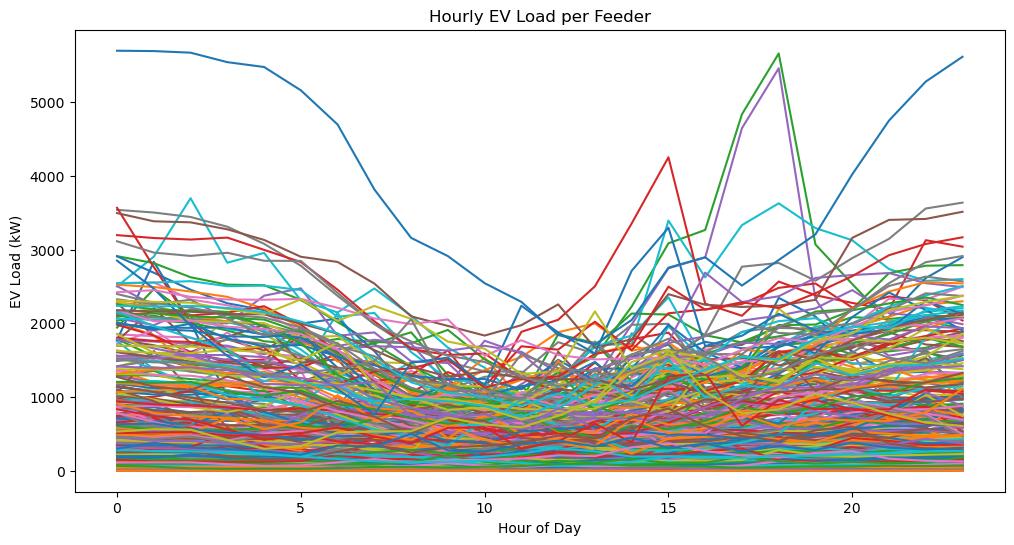

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- 1️⃣ Ensure hourly columns ----------------
# Only keep numeric columns representing hours
hourly_cols = [col for col in alamedaLoad2035Df.columns if col.isdigit()]

# Make a copy to avoid modifying original DataFrame
hourly_demand = alamedaLoad2035Df.copy()

# Ensure the index is numeric GEOID as string
hourly_demand.index = hourly_demand.index.astype(str)

# ---------------- 2️⃣ Ensure pivot table columns are strings ----------------
feederBlockMtxAlameda.columns = feederBlockMtxAlameda.columns.astype(str)

# ---------------- 3️⃣ Find common GEOIDs ----------------
common_geoids = hourly_demand.index.intersection(feederBlockMtxAlameda.columns)
print(f"Number of common GEOIDs: {len(common_geoids)}")

# Subset both DataFrames to only common GEOIDs
pivot_aligned = feederBlockMtxAlameda[common_geoids]
hourly_demand_aligned = hourly_demand.loc[common_geoids]

# ---------------- 4️⃣ Compute hourly feeder loads ----------------
# feeders x blocks dot blocks x hours → feeders x hours
feeder_hourly_load = pivot_aligned.dot(hourly_demand_aligned[hourly_cols])

# Optional: reset index to have 'feeder_id' as a column
feeder_hourly_load = feeder_hourly_load.reset_index().rename(columns={"index": "feeder_id"})

# ---------------- 6️⃣ Optional: Plot hourly load curves ----------------
plt.figure(figsize=(12,6))
for feeder in feeder_hourly_load["feeder_id"]:
    plt.plot(
        range(len(hourly_cols)),
        feeder_hourly_load.loc[feeder_hourly_load["feeder_id"] == feeder, hourly_cols].values.flatten(),
        label=feeder
    )

plt.xlabel("Hour of Day")
plt.ylabel("EV Load (kW)")
plt.title("Hourly EV Load per Feeder")
#plt.legend()
plt.show()


In [50]:
feeder_hourly_load.head()

,feeder_id,0,1,2,3,4,5,6,7,8,...,14,15,16,17,18,19,20,21,22,23
0,012011101,40.031558,41.224484,26.779246,26.690135,48.487692,74.380372,71.344274,63.162104,130.700484,...,81.851163,55.886192,61.511732,53.029135,48.690346,51.857712,65.837054,62.136398,56.363464,49.019175
1,012011102,54.409788,50.329388,33.575124,30.794003,37.885638,51.161609,73.998963,70.090775,100.638700,...,97.577251,113.073274,86.520937,67.962982,84.999001,77.087001,72.995754,72.303526,67.207721,63.327964
2,012011103,54.487163,49.989245,36.502114,35.932174,47.922587,67.686400,73.852254,76.984279,113.705189,...,104.689814,87.385955,80.760523,65.918650,52.556933,62.924274,67.786306,56.997115,52.803130,52.115674
3,012011104,53.567859,54.640325,40.320466,49.503829,50.383623,56.242733,97.307845,74.239833,87.050420,...,86.801501,85.133507,88.580559,69.289209,75.466644,83.126541,80.144813,82.571561,73.539509,61.162860
4,012011105,36.826286,34.889805,21.863877,21.030653,24.840697,35.033068,60.029622,45.016883,69.817030,...,66.108089,59.516368,57.659396,52.907942,63.990353,57.322456,55.620751,55.542818,50.060553,42.933860


In [51]:
import pandas as pd

# ---------------- 1️⃣ Standardize feeder IDs ----------------
def standardize_feeder_id(df, col="feeder_id", width=9):
    df[col] = df[col].astype(str).str.zfill(width)
    return df

feeder_hourly_load = standardize_feeder_id(feeder_hourly_load)
alamedaFeedersBaseLoadDf = standardize_feeder_id(alamedaFeedersBaseLoadDf)
alamedaMinICA = standardize_feeder_id(alamedaMinICA)

# ---------------- 2️⃣ Convert hourly EV loads to long format ----------------
hourly_cols = [str(h) for h in range(24)]  # "0" to "23"

feeder_hourly_long = feeder_hourly_load.melt(
    id_vars="feeder_id",
    value_vars=hourly_cols,
    var_name="hour",
    value_name="hrlyAvgEVLoadKW"
)

feeder_hourly_long["hour"] = feeder_hourly_long["hour"].astype(int)

# ---------------- 3️⃣ Merge with base load and min IC ----------------
feederStress = feeder_hourly_long.merge(
    alamedaFeedersBaseLoadDf[["feeder_id", "month", "hour", "high_load_kw"]],
    on=["feeder_id", "hour"],
    how="left"
)

feederStress = feederStress.merge(
    alamedaMinICA[["feeder_id", "month", "hour", "IC_min_kW"]],
    on=["feeder_id", "hour"],
    how="left"
)

# ---------------- 4️⃣ Compute hourly stress ----------------
feederStress["stress"] = (
    feederStress["high_load_kw"] + feederStress["hrlyAvgEVLoadKW"]
) / (feederStress["high_load_kw"] + feederStress["IC_min_kW"])

# ---------------- 5️⃣ Remove duplicates / aggregate if needed ----------------
# If you want one stress per feeder per hour (across months):
feederStress = feederStress.groupby(["feeder_id", "hour"])["stress"].mean().reset_index()

# ---------------- 6️⃣ Pivot to wide format ----------------
stress_wide = feederStress.pivot(index="feeder_id", columns="hour", values="stress")

# Optional: sort columns
stress_wide = stress_wide[sorted(stress_wide.columns)]

# ---------------- 7️⃣ Inspect results ----------------
stress_wide.head(20)


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
feeder_id,,,,,,,,,,,,,,,,,,,,,
012011101,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
012011102,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
012011103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
012011104,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
012011105,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
012011106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
012011108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
012011109,0.782885,0.772789,0.770753,0.766610,0.764409,0.799348,0.812612,0.816278,0.855790,0.845319,...,0.867083,0.886926,0.899576,0.878815,0.885006,0.865476,0.853388,0.859780,0.842683,0.805169
012011110,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
# Filter rows where IC_min_kW is NaN
missing_IC = alamedaMinICA[alamedaMinICA["IC_min_kW"].isna()]

# Show unique feeders with missing IC
feeders_missing_IC = missing_IC["feeder_id"].unique()

print("Feeders with missing IC_min_kW values:")
print(feeders_missing_IC)

# Optionally, display the full rows
display(missing_IC)


Feeders with missing IC_min_kW values:
['012011101' '012011102' '012011103' '012011104' '012011105' '012011106'
 '012041104' '012041112' '012060406' '012111111' '012111112' '012111113'
 '012111114' '012111115' '012111116' '013681111' '014722102']


,feeder_id,month,hour,IC_min_kW
0,012011101,1,0,NaN
1,012011101,1,1,NaN
2,012011101,1,2,NaN
3,012011101,1,3,NaN
4,012011101,1,4,NaN
...,...,...,...,...
84667,014722102,12,19,NaN
84668,014722102,12,20,NaN
84669,014722102,12,21,NaN
84670,014722102,12,22,NaN


In [53]:
alamedaMinICA

,feeder_id,month,hour,IC_min_kW
0,012011101,1,0,NaN
1,012011101,1,1,NaN
2,012011101,1,2,NaN
3,012011101,1,3,NaN
4,012011101,1,4,NaN
...,...,...,...,...
87259,169951101,12,19,1680.259033
87260,169951101,12,20,1257.512939
87261,169951101,12,21,1221.792725
87262,169951101,12,22,1106.435181


In [54]:
display(alamedaFeedersBaseLoadDf.head())


,feeder_id,month,hour,low_load_kw,high_load_kw
0,012011101,1,0,NaN,NaN
1,012011101,1,1,NaN,NaN
2,012011101,1,2,NaN,NaN
3,012011101,1,3,NaN,NaN
4,012011101,1,4,NaN,NaN


In [55]:
# Assume feeder_hourly_load has 'feeder_id' and columns '0'..'23'
feeder_hourly_long = feeder_hourly_load.melt(
    id_vars="feeder_id",
    value_vars=[str(h) for h in range(24)],
    var_name="hour",
    value_name="hrlyAvgEVLoadKW"
)

# Ensure hour is integer for merging
feeder_hourly_long["hour"] = feeder_hourly_long["hour"].astype(int)
feeder_hourly_long

,feeder_id,hour,hrlyAvgEVLoadKW
0,012011101,0,40.031558
1,012011102,0,54.409788
2,012011103,0,54.487163
3,012011104,0,53.567859
4,012011105,0,36.826286
...,...,...,...
7267,014722111,23,607.659806
7268,082831109,23,266.991877
7269,163741102,23,311.564521
7270,163741103,23,0.191475


### For exporting feeders only

In [56]:
# Make sure feeder IDs are strings with matching formatting
alamedaFeedersBaseLoadDf["feeder_id"] = alamedaFeedersBaseLoadDf["feeder_id"].astype(str)
feederMetadataGdf["feeder_id"] = feederMetadataGdf["feeder_id"].astype(str)

# ---------------- 2️⃣ Get unique Alameda feeders ----------------
alameda_feeders = alamedaFeedersBaseLoadDf["feeder_id"].unique()

# ---------------- 3️⃣ Filter feeder metadata ----------------
alamedaMetadataGdf = feederMetadataGdf[feederMetadataGdf["feeder_id"].isin(alameda_feeders)].copy()

# ---------------- 4️⃣ Optional: assign unique colors for Kepler ----------------
import random
import string

def random_color_hex():
    return "#" + ''.join(random.choices("0123456789ABCDEF", k=6))

alamedaMetadataGdf["color"] = [random_color_hex() for _ in range(len(alamedaMetadataGdf))]

# ---------------- 5️⃣ Export for Kepler ----------------
alamedaMetadataGdf.to_file("alameda_feeders_for_kepler.geojson", driver="GeoJSON")

print("Alameda feeder metadata exported. Number of feeders:", len(alamedaMetadataGdf))


Alameda feeder metadata exported. Number of feeders: 303


In [57]:
print(alamedaMetadataGdf.crs)

# Convert CRS to WGS84 for Kepler
alamedaMetadataGdf = alamedaMetadataGdf.to_crs(epsg=4326)

# Export to GeoJSON
alamedaMetadataGdf.to_file("alameda_feeders_for_kepler.geojson", driver="GeoJSON")


EPSG:26910


In [ ]:
print(alamedaMetadataGdf.geom_type.value_counts())

In [ ]:
alamedaMetadataGdf

### Export feeders with peak stress over morning, afternoon, evening

In [47]:
import geopandas as gpd
import pandas as pd

# ---------------- 1️⃣ Ensure feeder IDs are strings ----------------
alamedaMetadataGdf["feeder_id"] = alamedaMetadataGdf["feeder_id"].astype(str)
feederStress["feeder_id"] = feederStress["feeder_id"].astype(str)

# ---------------- 2️⃣ Define time bins ----------------
# 0-23 hour mapping to time periods:
# Night: 20-23 & 0-5 → combine into one group
# Morning: 5-10
# Daytime: 10-20

def assign_time_period(hour):
    if hour >= 20 or hour < 5:
        return "nighttime"
    elif 5 <= hour < 10:
        return "morning"
    else:  # 10 <= hour < 20
        return "daytime"

feederStress["time_period"] = feederStress["hour"].apply(assign_time_period)

# ---------------- 3️⃣ Aggregate peak stress per feeder × time_period ----------------
peak_stress = (
    feederStress.groupby(["feeder_id", "time_period"])["stress"]
    .max()
    .reset_index()
)

# ---------------- 4️⃣ Merge with metadata ----------------
feeder_stress_export = peak_stress.merge(
    alamedaMetadataGdf[["feeder_id", "geometry", "color"]],
    on="feeder_id",
    how="left"
)

# ---------------- 5️⃣ Optional: inspect ----------------
display(feeder_stress_export.head())  # should show 3 rows per feeder


NameError: name 'feederStress' is not defined

In [ ]:
# ---------------- Export separate GeoJSONs for each time period ----------------

for period in ["nighttime", "morning", "daytime"]:
    gdf_period = feeder_stress_export[feeder_stress_export["time_period"] == period].copy()
    
    # Convert to GeoDataFrame
    gdf_period = gpd.GeoDataFrame(gdf_period, geometry="geometry", crs=alamedaMetadataGdf.crs)

    # Export
    out_file = f"feeder_stress_{period}.geojson"
    gdf_period.to_file(out_file, driver="GeoJSON")
    print(f"Exported {len(gdf_period)} rows → {out_file}")


### Hourly Export

In [46]:
import geopandas as gpd
import pandas as pd

# ---------------- 1️⃣ Ensure feeder IDs are strings ----------------
alamedaMetadataGdf["feeder_id"] = alamedaMetadataGdf["feeder_id"].astype(str)
feederStress["feeder_id"] = feederStress["feeder_id"].astype(str)

# ---------------- 2️⃣ Keep only odd hours ----------------
feederStress_odd = feederStress[feederStress["hour"] % 2 == 1].copy()

# ---------------- 3️⃣ Merge with metadata ----------------
feederStress_odd = feederStress_odd.merge(
    alamedaMetadataGdf[["feeder_id", "geometry", "color"]],
    on="feeder_id",
    how="left"
)

# ---------------- 4️⃣ Optional: inspect ----------------
display(feederStress_odd.head())  # should show one row per feeder per odd hour


NameError: name 'feederStress' is not defined

In [ ]:
import geopandas as gpd

# ---------------- 1️⃣ Convert to GeoDataFrame ----------------
feederStress_odd_gdf = gpd.GeoDataFrame(
    feederStress_odd,
    geometry="geometry",
    crs=alamedaMetadataGdf.crs  # keep same CRS as your metadata
)

# ---------------- 2️⃣ Export to GeoJSON ----------------
feederStress_odd.to_file("alameda_feeders_odd_hours.geojson", driver="GeoJSON")

print("Export complete. Rows:", len(kepler_gdf))


### Every 3 hours: 

In [59]:
import geopandas as gpd
import pandas as pd

# ---------------- 1️⃣ Ensure feeder IDs are strings ----------------
alamedaMetadataGdf["feeder_id"] = alamedaMetadataGdf["feeder_id"].astype(str)
feederStress["feeder_id"] = feederStress["feeder_id"].astype(str)

# ---------------- 2️⃣ Define 3-hour period hours ----------------
hours_3hr = list(range(0, 24, 3))   # [0, 3, 6, 9, 12, 15, 18, 21]

# ---------------- 3️⃣ Filter to 3-hour blocks ----------------
feederStress_3hr = feederStress[feederStress["hour"].isin(hours_3hr)].copy()

# ---------------- 4️⃣ Merge with metadata ----------------
feederStress_3hr = feederStress_3hr.merge(
    alamedaMetadataGdf[["feeder_id", "geometry", "color"]],
    on="feeder_id",
    how="left"
)
feederStress_3hr.head()

,feeder_id,hour,stress,geometry,color
0,012011101,0,NaN,"MULTILINESTRING ((-122.27233 37.802, -122.2723...",#F49C06
1,012011101,3,NaN,"MULTILINESTRING ((-122.27233 37.802, -122.2723...",#F49C06
2,012011101,6,NaN,"MULTILINESTRING ((-122.27233 37.802, -122.2723...",#F49C06
3,012011101,9,NaN,"MULTILINESTRING ((-122.27233 37.802, -122.2723...",#F49C06
4,012011101,12,NaN,"MULTILINESTRING ((-122.27233 37.802, -122.2723...",#F49C06


In [61]:
# ---------------- 5️⃣ Convert merged to GeoDataFrame ----------------
feederStress_3hr_gdf = gpd.GeoDataFrame(
    feederStress_3hr, 
    geometry="geometry", 
    crs=alamedaMetadataGdf.crs
)

# # ---------------- 6️⃣ Export one GeoJSON per 3-hour block ----------------
# for hr in hours_3hr:
#     gdf_hr = feederStress_3hr_gdf[feederStress_3hr_gdf["hour"] == hr].copy()
#     outfile = f"feeder_stress_hour_{hr}.geojson"
#     gdf_hr.to_file(outfile, driver="GeoJSON")
#     print(f"Saved {len(gdf_hr)} rows → {outfile}")

gdf_hr = feederStress_3hr_gdf[feederStress_3hr_gdf["hour"] == 21].copy()
outfile = f"feeder_stress_hour_{21}.geojson"
gdf_hr.to_file(outfile, driver="GeoJSON")
print(f"Saved {len(gdf_hr)} rows → {outfile}")

Saved 303 rows → feeder_stress_hour_21.geojson


## Plot hourly EV load, instead of stress

In [ ]:
import pandas as pd

# ---------------- 1️⃣ Standardize feeder IDs ----------------
def standardize_feeder_id(df, col="feeder_id", width=9):
    df[col] = df[col].astype(str).str.zfill(width)
    return df

feeder_hourly_load = standardize_feeder_id(feeder_hourly_load)
alamedaFeedersBaseLoadDf = standardize_feeder_id(alamedaFeedersBaseLoadDf)
alamedaMinICA = standardize_feeder_id(alamedaMinICA)

# ---------------- 2️⃣ Convert hourly EV loads to long format ----------------
hourly_cols = [str(h) for h in range(24)]  # "0" to "23"

feeder_hourly_long = feeder_hourly_load.melt(
    id_vars="feeder_id",
    value_vars=hourly_cols,
    var_name="hour",
    value_name="hrlyAvgEVLoadKW"
)

feeder_hourly_long["hour"] = feeder_hourly_long["hour"].astype(int)

# ---------------- 3️⃣ Merge with base load and min IC ----------------
resultsDf = feeder_hourly_long.merge(
    alamedaFeedersBaseLoadDf[["feeder_id", "month", "hour", "high_load_kw"]],
    on=["feeder_id", "hour"],
    how="left"
)

resultsDf = resultsDf.merge(
    alamedaMinICA[["feeder_id", "month", "hour", "IC_min_kW"]],
    on=["feeder_id", "hour"],
    how="left"
)
evFeederLoad = resultsDf
# ---------------- 4️⃣ Compute hourly stress ----------------
evFeederLoad["EV_load"] = resultsDf["hrlyAvgEVLoadKW"]


# ---------------- 5️⃣ Remove duplicates / aggregate if needed ----------------
# If you want one hrlyAvgEVLoadKW per feeder per hour (across months):
evFeederLoad = evFeederLoad.groupby(["feeder_id", "hour"])["hrlyAvgEVLoadKW"].mean().reset_index()

# # ---------------- 6️⃣ Pivot to wide format ----------------
# stress_wide = resultsDf_unique.pivot(index="feeder_id", columns="hour", values="stress")

# # Optional: sort columns
# stress_wide = stress_wide[sorted(stress_wide.columns)]

# # ---------------- 7️⃣ Inspect results ----------------
# stress_wide.head(20)


In [ ]:
evFeederLoad.head(50)


In [ ]:
import geopandas as gpd
import pandas as pd

# # ---------------- 1️⃣ Ensure feeder IDs are strings ----------------
# alamedaMetadataGdf["feeder_id"] = alamedaMetadataGdf["feeder_id"].astype(str)
# resultsDf_unique["feeder_id"] = resultsDf_unique["feeder_id"].astype(str)

# ---------------- 2️⃣ Define time bins ----------------
# 0-23 hour mapping to time periods:
# Night: 20-23 & 0-5 → combine into one group
# Morning: 5-10
# Daytime: 10-20

def assign_time_period(hour):
    if hour >= 20 or hour < 5:
        return "nighttime"
    elif 5 <= hour < 10:
        return "morning"
    else:  # 10 <= hour < 20
        return "daytime"

evFeederLoad["time_period"] = evFeederLoad["hour"].apply(assign_time_period)

# ---------------- 3️⃣ Aggregate peak stress per feeder × time_period ----------------
peak_load = (
    evFeederLoad.groupby(["feeder_id", "time_period"])["hrlyAvgEVLoadKW"]
    .max()
    .reset_index()
)

# ---------------- 4️⃣ Merge with metadata ----------------
kepler_df_1 = peak_load.merge(
    alamedaMetadataGdf[["feeder_id", "geometry", "color"]],
    on="feeder_id",
    how="left"
)

# ---------------- 5️⃣ Optional: inspect ----------------
display(kepler_df_1.head())  # should show 3 rows per feeder


In [ ]:
import geopandas as gpd

# Convert to GeoDataFrame if you have a 'geometry' column
kepler_gdf = gpd.GeoDataFrame(kepler_df_1, geometry="geometry", crs="EPSG:26910")  # or use the CRS of your data

# Export to GeoJSON
kepler_gdf.to_file("evLoadFeeders.geojson", driver="GeoJSON")

print("Export complete. Rows:", len(kepler_gdf))

# Export to GeoJSON
kepler_gdf.to_file("evLoadFeeders.geojson", driver="GeoJSON")

In [ ]:
import geopandas as gpd

# Ensure it's a GeoDataFrame
kepler_gdf = gpd.GeoDataFrame(kepler_df_1, geometry="geometry", crs="EPSG:26910")

# Export morning
kepler_gdf[kepler_gdf["time_period"] == "morning"].to_file(
    "evLoadFeeders_morning.geojson", driver="GeoJSON"
)

# Export daytime
kepler_gdf[kepler_gdf["time_period"] == "daytime"].to_file(
    "evLoadFeeders_daytime.geojson", driver="GeoJSON"
)

# Export nighttime
kepler_gdf[kepler_gdf["time_period"] == "nighttime"].to_file(
    "evLoadFeeders_nighttime.geojson", driver="GeoJSON"
)


## Plot public and private charging over time

In [ ]:


base_path=DATA_DIR
relative_folder_path = "EVChargingLoadCurves/sim_20251121_alameda_2035_managed_naive"
filename = "ev_load_curves_managed.csv"
file_path = os.path.join(base_path, relative_folder_path, filename)
managed_EV_load = gpd.read_file(file_path)

managed_EV_load

In [ ]:
import pandas as pd
import geopandas as gpd

# Make a copy to be safe
gdf = private_EV_load.copy()

# -------------------------------
# 1. Extract the first row as header
# -------------------------------
new_cols = gdf.iloc[0].tolist()

# Replace current column names
gdf.columns = new_cols

# -------------------------------
# 2. Drop the header row but KEEP geometry aligned
# -------------------------------
gdf = gdf.drop(index=0).reset_index(drop=True)

# -------------------------------
# 3. Convert back to GeoDataFrame (geometry is still intact)
# -------------------------------
private_EV_load_clean = gpd.GeoDataFrame(gdf, geometry="geometry", crs=private_EV_load.crs)

private_EV_load_clean.head()
